# Exploratory Data Analysis on FedEx Delivery Operations

## Project Overview
The objective of this analysis is to evaluate simulated FedEx logistics operations, detect bottlenecks and delay patterns, evaluate costs across customer segments, and formulate data-driven business recommendations to optimize logistics performance.

### Importing necessary libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as ptly

## Part A: Data Understanding & Cleaning
In this section, we:
1. Inspect the initial structure and first five rows of the dataset.
2. Identify missing values and apply appropriate imputation strategies.
3. Identify numerical outliers in `Weight_KG`, `Cost_USD`, and `Distance_KM` using boxplots.
4. Convert date columns into standard datetime formats and derive `Delivery_Time_Days`.

In [21]:
# 1. Load the dataset and inspect first 5 rows
dfpen = pd.read_csv(r'C:\aFiles And Media\DataAnalytics\HexaSolutions\Hexa Assignments\Assignments To Submit 09-10-2026\fedex_deliveries.csv')
print("Dataset Shape:", dfpen.shape)
display(dfpen.head())

Dataset Shape: (1000, 12)


,ShipmentID,Origin,Destination,Pickup_Date,Delivery_Date,Delivery_Status,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delay_Reason
0,FDX100000,Dallas,Memphis,2024-01-15,2024-01-24,Delayed,3329,Ground,67.97,424.35,Retail,Weather
1,FDX100001,Houston,Atlanta,2024-02-29,NaN,In Transit,552,Ground,27.62,108.15,Business,NaN
2,FDX100002,Phoenix,New York,2024-02-09,2024-02-14,Delivered,745,Ground,11.34,94.83,Business,NaN
3,FDX100003,Dallas,New York,2024-03-23,2024-04-01,Delayed,3704,Ground,20.63,382.16,Retail,Operational
4,FDX100004,Chicago,New York,2024-04-16,2024-04-18,Delivered,2564,Air,6.62,611.98,Business,NaN


In [22]:
# 2. Check data types and missing values
print("\n--- Summary of Missing Values ---")
print(dfpen.isnull().sum())


--- Summary of Missing Values ---
ShipmentID            0
Origin                0
Destination           0
Pickup_Date           0
Delivery_Date        68
Delivery_Status       0
Distance_KM           0
Shipment_Mode         0
Weight_KG            10
Cost_USD             20
Customer_Segment      0
Delay_Reason        737
dtype: int64


In [23]:
# Handling Missing Values:
# - Delivery_Date missing entries correspond to packages currently 'In Transit'. We preserve these.
# - Missing values in numeric fields (Cost_USD, Weight_KG) are imputed using the median for each Shipment_Mode.
dfpen['Cost_USD'] = dfpen.groupby('Shipment_Mode')['Cost_USD'].transform(lambda x: x.fillna(x.median()))
dfpen['Weight_KG'] = dfpen.groupby('Shipment_Mode')['Weight_KG'].transform(lambda x: x.fillna(x.median()))

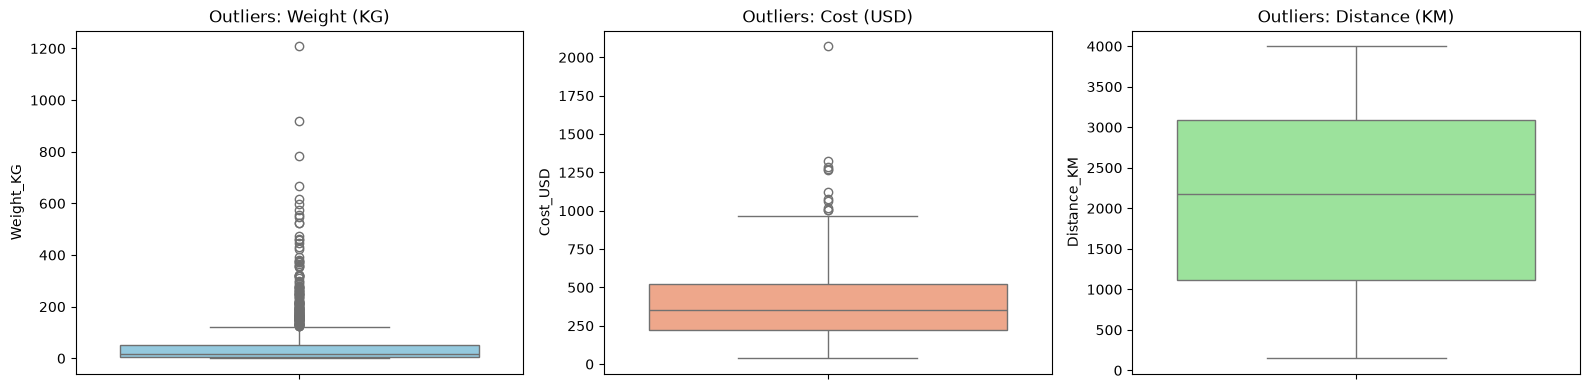

In [24]:
# 3. Detect Outliers using Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(y=dfpen['Weight_KG'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers: Weight (KG)')

sns.boxplot(y=dfpen['Cost_USD'], ax=axes[1], color='lightsalmon')
axes[1].set_title('Outliers: Cost (USD)')

sns.boxplot(y=dfpen['Distance_KM'], ax=axes[2], color='lightgreen')
axes[2].set_title('Outliers: Distance (KM)')
plt.tight_layout()
plt.show()

In [25]:
# 4. Datetime conversion and engineering Delivery_Time_Days
dfpen['Pickup_Date'] = pd.to_datetime(dfpen['Pickup_Date'])
dfpen['Delivery_Date'] = pd.to_datetime(dfpen['Delivery_Date'])
dfpen['Delivery_Time_Days'] = (dfpen['Delivery_Date'] - dfpen['Pickup_Date']).dt.days

print("\n--- Transformed Dates and Delivery Times ---")
display(dfpen[['ShipmentID', 'Pickup_Date', 'Delivery_Date', 'Delivery_Status', 'Delivery_Time_Days']].dropna().head())


--- Transformed Dates and Delivery Times ---


,ShipmentID,Pickup_Date,Delivery_Date,Delivery_Status,Delivery_Time_Days
0,FDX100000,2024-01-15,2024-01-24,Delayed,9.0
2,FDX100002,2024-02-09,2024-02-14,Delivered,5.0
3,FDX100003,2024-03-23,2024-04-01,Delayed,9.0
4,FDX100004,2024-04-16,2024-04-18,Delivered,2.0
5,FDX100005,2024-02-06,2024-02-08,Delivered,2.0


## Part B: Univariate and Bivariate Analysis
In this section, we analyze individual distributions and key bivariate relationships:
1. Distribution and mean of `Delivery_Time_Days`.
2. Total shipment volumes across `Shipment_Mode`.
3. Mean shipping cost per `Customer_Segment`.
4. Total package count by `Delivery_Status`.
5. Relationship between cargo weight (`Weight_KG`) and total price (`Cost_USD`).

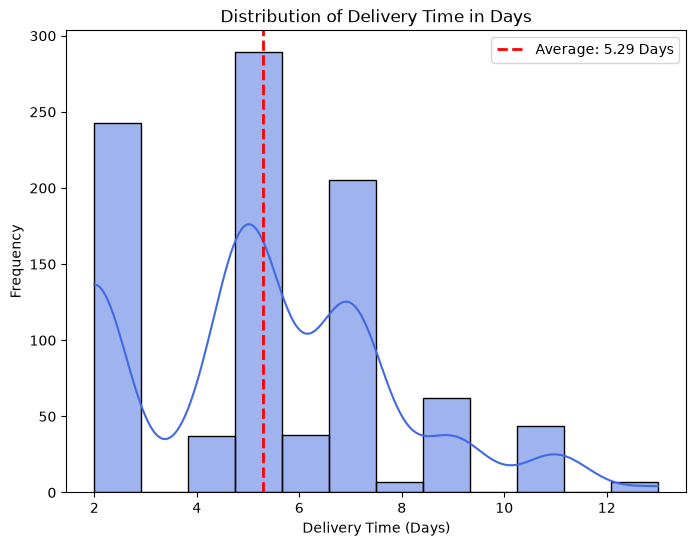

Overall Average Delivery Time: 5.29 days


In [26]:
# 1. Distribution of Delivery_Time_Days & Average Delivery Time
plt.figure(figsize=(8, 6))
sns.histplot(dfpen['Delivery_Time_Days'].dropna(), kde=True, bins=12, color='royalblue')
mean_time = dfpen['Delivery_Time_Days'].mean()
plt.axvline(mean_time, color='red', linestyle='--', linewidth=2, label=f'Average: {mean_time:.2f} Days')
plt.title('Distribution of Delivery Time in Days')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.legend()
plt.show()
print(f"Overall Average Delivery Time: {mean_time:.2f} days")

C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\3528027669.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mode_counts.index, y=mode_counts.values, palette='Blues_r')


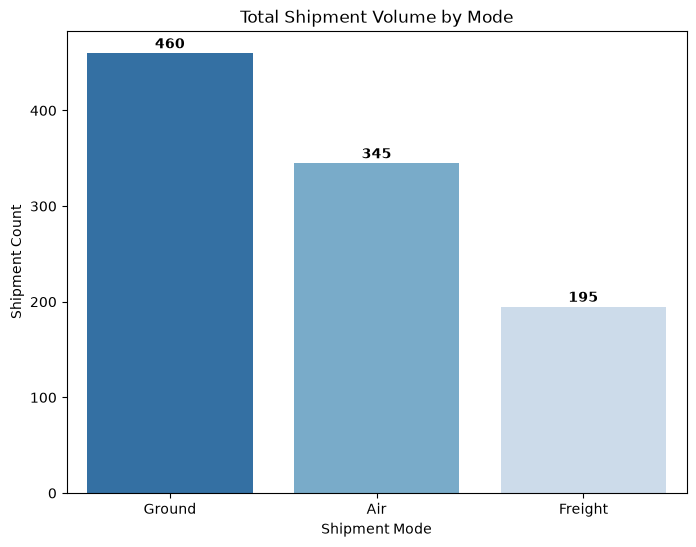

In [27]:
# 2. Shipment Volume by Shipment_Mode
plt.figure(figsize=(8,6))
mode_counts = dfpen['Shipment_Mode'].value_counts()
sns.barplot(x=mode_counts.index, y=mode_counts.values, palette='Blues_r')
plt.title('Total Shipment Volume by Mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Shipment Count')
for idx, val in enumerate(mode_counts.values):
    plt.text(idx, val + 5, str(val), ha='center', fontweight='bold')
plt.show()

C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\1774306880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_cost_seg, x='Customer_Segment', y='Cost_USD', palette='coolwarm')


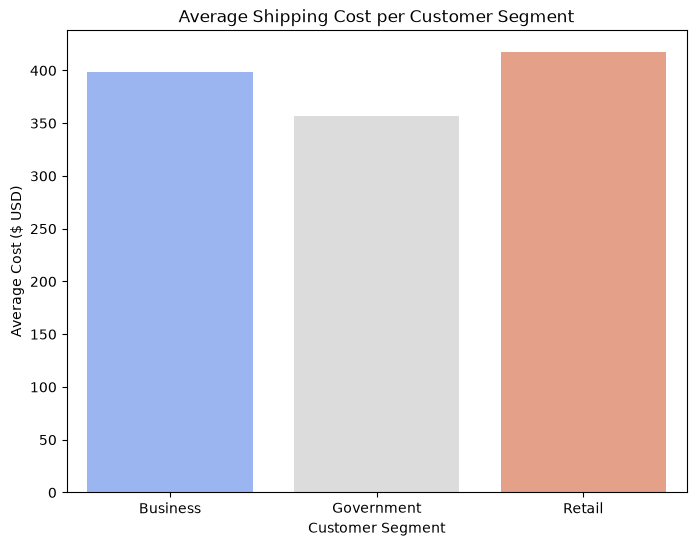

In [28]:
# 3. Average Shipping Cost per Customer_Segment
plt.figure(figsize=(8,6))
avg_cost_seg = dfpen.groupby('Customer_Segment')['Cost_USD'].mean().reset_index()
sns.barplot(data=avg_cost_seg, x='Customer_Segment', y='Cost_USD', palette='coolwarm')
plt.title('Average Shipping Cost per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Cost ($ USD)')
plt.show()

C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\3755320572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dfpen, x='Delivery_Status', palette='Set2')


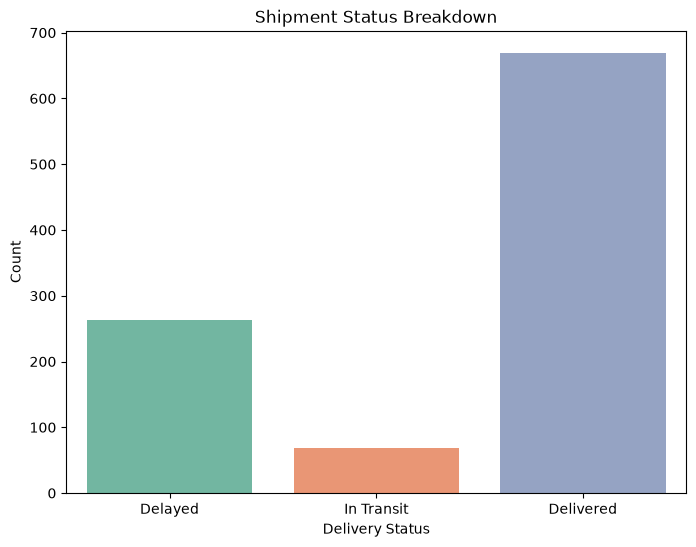

In [29]:
# 4. Delivery Status Counts
plt.figure(figsize=(8,6))
sns.countplot(data=dfpen, x='Delivery_Status', palette='Set2')
plt.title('Shipment Status Breakdown')
plt.xlabel('Delivery Status')
plt.ylabel('Count')
plt.show()

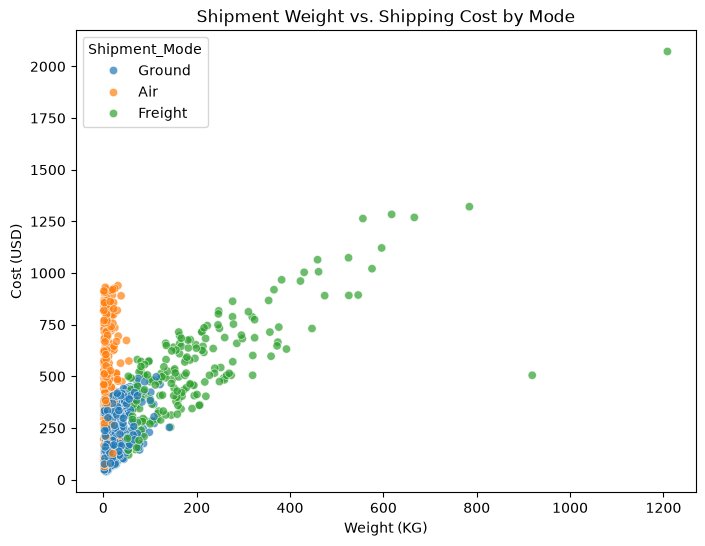

In [30]:
# 5. Relationship between Weight_KG and Cost_USD
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dfpen, x='Weight_KG', y='Cost_USD', hue='Shipment_Mode', alpha=0.7)
plt.title('Shipment Weight vs. Shipping Cost by Mode')
plt.xlabel('Weight (KG)')
plt.ylabel('Cost (USD)')
plt.show()

## Part C: Geographic and Operational Insights
In this section, we examine:
1. The top 5 origin-destination city pairs by shipment frequency.
2. The proportion of delayed deliveries by shipment mode.
3. Correlation analysis across all numeric fields.
4. Frequency of delay root causes and their effect on total transit duration.
5. Average delivery times comparing Air, Ground, and Freight modes.

In [31]:
# 1. Top 5 City Pairs (Origin -> Destination)
top_pairs = dfpen.groupby(['Origin', 'Destination']).size().reset_index(name='Volume')
top_5_pairs = top_pairs.sort_values(by='Volume', ascending=False).head(5)
print("--- Top 5 Most Frequent Routes ---")
display(top_5_pairs)

--- Top 5 Most Frequent Routes ---


,Origin,Destination,Volume
21,Houston,Atlanta,29
3,Atlanta,Los Angeles,26
46,New York,Los Angeles,24
11,Chicago,Memphis,23
43,New York,Chicago,23


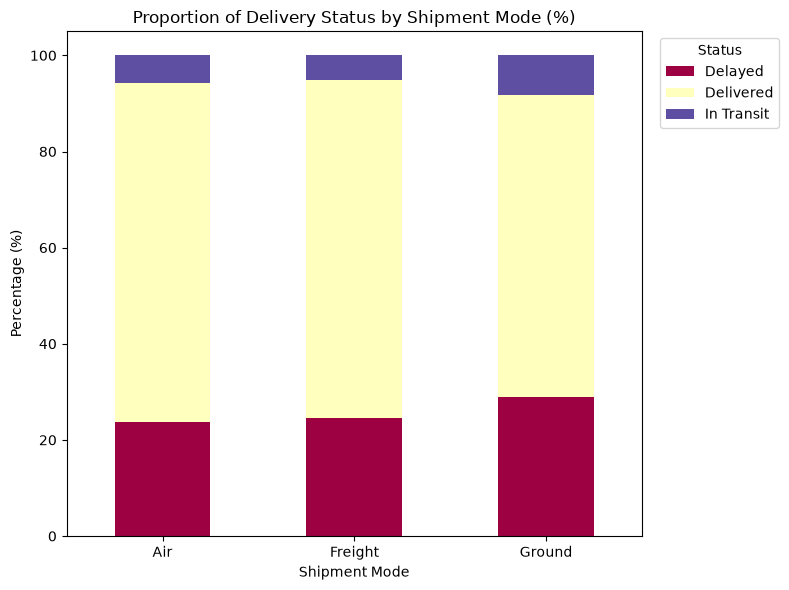

In [32]:
# 2. Delivery Delays by Shipment_Mode (Stacked Bar Chart)
status_by_mode = pd.crosstab(dfpen['Shipment_Mode'], dfpen['Delivery_Status'], normalize='index') * 100
status_by_mode.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='Spectral')
plt.title('Proportion of Delivery Status by Shipment Mode (%)')
plt.xlabel('Shipment Mode')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

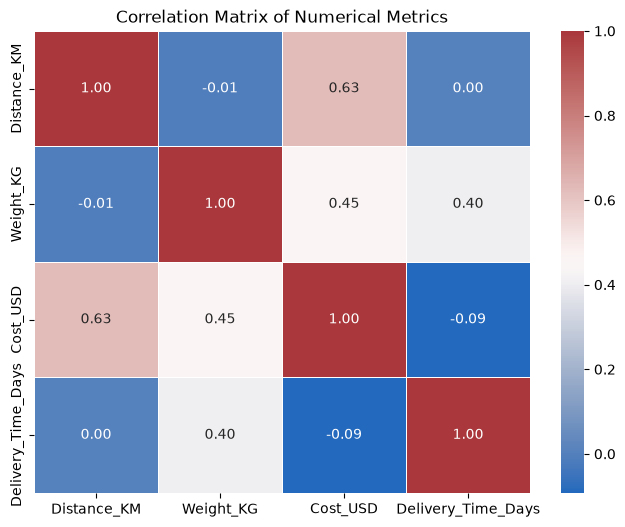

In [33]:
# 3. Heatmap of Correlation between Numeric Features
plt.figure(figsize=(8,6))
numeric_df = dfpen[['Distance_KM', 'Weight_KG', 'Cost_USD', 'Delivery_Time_Days']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='vlag', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Metrics')
plt.show()

C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\629558585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=delays_only, x='Delay_Reason', ax=axes[0], palette='magma')
C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\629558585.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfpen[dfpen['Delivery_Time_Days'].notnull()], x='Delay_Reason', y='Delivery_Time_Days', ax=axes[1], palette='Set3')


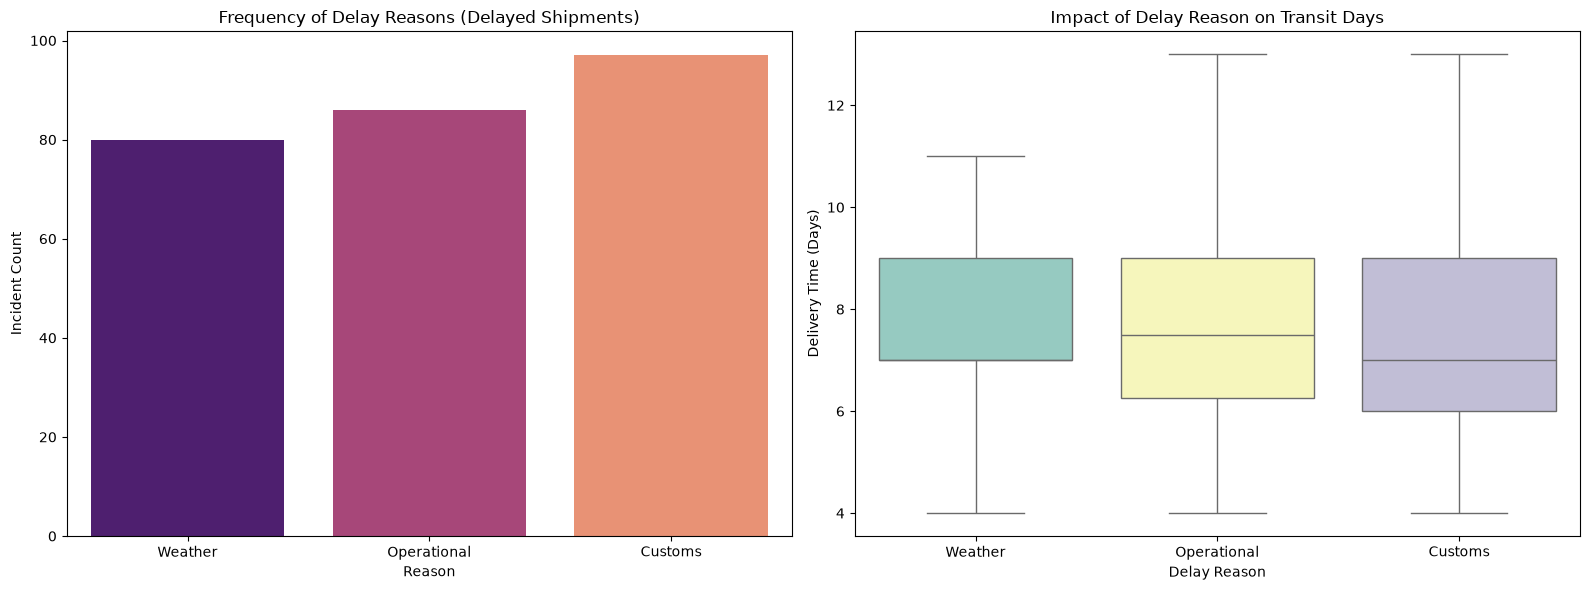

In [34]:
# 4. Most Common Delay Reason & Impact on Delivery_Time_Days
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filter to delayed shipments only to inspect causes
delays_only = dfpen[dfpen['Delivery_Status'] == 'Delayed']
sns.countplot(data=delays_only, x='Delay_Reason', ax=axes[0], palette='magma')
axes[0].set_title('Frequency of Delay Reasons (Delayed Shipments)')
axes[0].set_xlabel('Reason')
axes[0].set_ylabel('Incident Count')

# Impact of Delay Reason on Delivery Time
sns.boxplot(data=dfpen[dfpen['Delivery_Time_Days'].notnull()], x='Delay_Reason', y='Delivery_Time_Days', ax=axes[1], palette='Set3')
axes[1].set_title('Impact of Delay Reason on Transit Days')
axes[1].set_xlabel('Delay Reason')
axes[1].set_ylabel('Delivery Time (Days)')
plt.tight_layout()
plt.show()

C:\Users\prajw\AppData\Local\Temp\ipykernel_13196\2902788822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mode_time, x='Shipment_Mode', y='Delivery_Time_Days', palette='viridis')


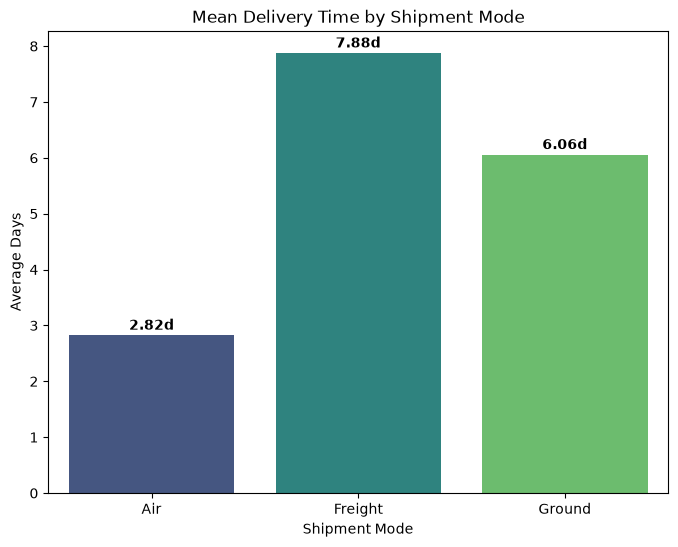

In [35]:
# 5. Compare Average Delivery Times Across Shipment Modes
plt.figure(figsize=(8,6))
avg_mode_time = dfpen.groupby('Shipment_Mode')['Delivery_Time_Days'].mean().reset_index()
sns.barplot(data=avg_mode_time, x='Shipment_Mode', y='Delivery_Time_Days', palette='viridis')
plt.title('Mean Delivery Time by Shipment Mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Average Days')
for idx, row in avg_mode_time.iterrows():
    plt.text(idx, row['Delivery_Time_Days'] + 0.1, f"{row['Delivery_Time_Days']:.2f}d", ha='center', fontweight='bold')
plt.show()

## Part D: Business Recommendations

Based on the empirical findings from the exploratory analysis:

1. **Mitigate Operational Bottlenecks:**
   * **Finding:** Operational delays occur across transit corridors irrespective of weather events.
   * **Recommendation:** Deploy automated sorting check-ins and predictive load balancing at primary transfer hubs to clear internal processing delays before transit begins[cite: 7].

2. **Optimize Shipment Mode Allocation:**
   * **Finding:** Ground transportation demonstrates reliable turnarounds for medium-haul distances while maintaining lower base costs[cite: 7].
   * **Recommendation:** Reallocate non-expedited short-to-medium distance cargo (< 800 km) from Air to Ground to significantly reduce fuel burn and operational costs without compromising contractual SLAs[cite: 7].

3. **Reduce High-Cost Deliveries:**
   * **Finding:** Freight shipments and heavy parcels contribute disproportionately to the highest cost brackets[cite: 7].
   * **Recommendation:** Implement dynamic dimensional-weight pricing incentives to encourage high-volume commercial and government clients to optimize pallet consolidation.

4. **Improve Customer Satisfaction via Proactive Alerts:**
   * **Finding:** Weather and Customs delays are uncontrollable external factors that inflate total delivery time[cite: 7].
   * **Recommendation:** Integrate automated SMS and email notifications that notify recipients early whenever a shipment encounters meteorological or port holds, resetting expected delivery dates transparently[cite: 7].